# U.S. Medical Insurance Costs

# Import a dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Connecting Google Drive
from google.colab import drive
drive.mount("/content/drive")

# Changing work folder
%cd /content/drive/MyDrive/codeacademy/Projects/US_Medical_Insurance_Costs/python-portfolio-project-starter-files/

# import CSV file
df = pd.read_csv("insurance.csv")
df.head()

Mounted at /content/drive
/content/drive/MyDrive/codeacademy/Projects/US_Medical_Insurance_Costs/python-portfolio-project-starter-files


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# Data overview

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [3]:
print(df.shape)

(1338, 7)


In [4]:
print(f"Columns: {list(df.columns)}\n")

Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']



In [5]:
# for non-numeric **categorical** columns count - see all unique values, their number, and also determine which data occurs most often / least often:
# Select only object-type columns
object_columns = df.select_dtypes(include='object').columns
for col in object_columns:
    print(f"--- Column: {col} ---")
    unique_values = df[col].unique()
    print("Unique Values:", unique_values)
    print("Number of Unique Values:", len(unique_values))
    print("\n")

--- Column: sex ---
Unique Values: ['female' 'male']
Number of Unique Values: 2


--- Column: smoker ---
Unique Values: ['yes' 'no']
Number of Unique Values: 2


--- Column: region ---
Unique Values: ['southwest' 'southeast' 'northwest' 'northeast']
Number of Unique Values: 4




In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
# Quick correlation and smoker impact check to inform the plan
import numpy as np

# Convert categorical to numeric for correlation
df_numeric = df.copy()
df_numeric['sex'] = df_numeric['sex'].map({'female': 0, 'male': 1}) #Label Encoded (manually mapped)
df_numeric['smoker'] = df_numeric['smoker'].map({'no': 0, 'yes': 1}) #Label Encoded (manually mapped)
df_numeric = pd.get_dummies(df_numeric, columns=['region']) #One-Hot Encoded

print("Correlations with Charges:")
print(df_numeric.corr()['charges'].sort_values(ascending=False))

print("\nMean charges by smoker status:")
print(df.groupby('smoker')['charges'].mean())

print("\nMean charges by age groups (binned):")
df['age_group'] = pd.cut(df['age'], bins=[17, 30, 45, 65], labels=['Young', 'Middle', 'Senior'])
print(df.groupby('age_group', observed=True)['charges'].mean())

Correlations with Charges:
charges             1.000000
smoker              0.787251
age                 0.299008
bmi                 0.198341
region_southeast    0.073982
children            0.067998
sex                 0.057292
region_northeast    0.006349
region_northwest   -0.039905
region_southwest   -0.043210
Name: charges, dtype: float64

Mean charges by smoker status:
smoker
no      8434.268298
yes    32050.231832
Name: charges, dtype: float64

Mean charges by age groups (binned):
age_group
Young      9397.552051
Middle    12647.455654
Senior    17200.428704
Name: charges, dtype: float64


We can identify **lifestyle choices** and **demographic factors** as the primary predictors of medical insurance charges. The most significant finding is the overwhelming impact of smoking status on total costs.

### 1. The "Smoker" Effect: The Primary Cost Driver

The data shows a massive disparity in costs based on smoking habits:

* **Correlation:** Smoking has a high positive correlation of **0.79**, indicating it is the strongest predictor of high charges in this dataset.
* **Cost Gap:** On average, smokers are charged **\$32,050**, while non-smokers are charged only **\$8,434**.
* **Insight:** A smoker’s charges are nearly **4x higher** than those of a non-smoker. This suggests that smoking cessation programs could be the most effective way to reduce overall insurance payouts.


### 2. The Impact of Aging

While not as drastic as smoking, age remains a steady contributor to rising costs:

* **Correlation:** Age shows a moderate positive correlation of **0.30**.
* **Binned Analysis:** There is a clear "step-up" in costs as patients move through life stages:
* **Seniors** pay roughly **83% more** than **Young** adults.
* **Middle-aged** patients represent a mid-point transition, paying about **34% more** than the youngest group.

* **Insight:** The data confirms a predictable, linear increase in healthcare utilization as the population ages.


### 3. Secondary Factors: BMI and Demographics

The remaining variables play a much smaller role in determining charges:

* **BMI (0.20):** Body Mass Index has a weak-to-moderate correlation. While high BMI increases risk, it is a less consistent predictor of cost than smoking or age in this specific group.
* **Geography and Household:** Factors like **region**, **number of children**, and **sex** show near-zero correlations (all < 0.08).
* **Insight:** For this dataset, **where** someone lives or their **gender** has almost no statistical impact on what they are charged compared to **how** they live (smoking) and **how old** they are.

### Summary Table

| Factor | Strength of Impact | Key Takeaway |
| --- | --- | --- |
| **Smoking** | **Very High** | Increases charges by ~$23,600 on average. |
| **Age** | **Moderate** | Costs rise significantly between "Young" and "Senior" groups. |
| **BMI** | **Low/Moderate** | Influences costs, but less than lifestyle and age. |
| **Region/Sex** | **Negligible** | These factors are not meaningful predictors of cost. |


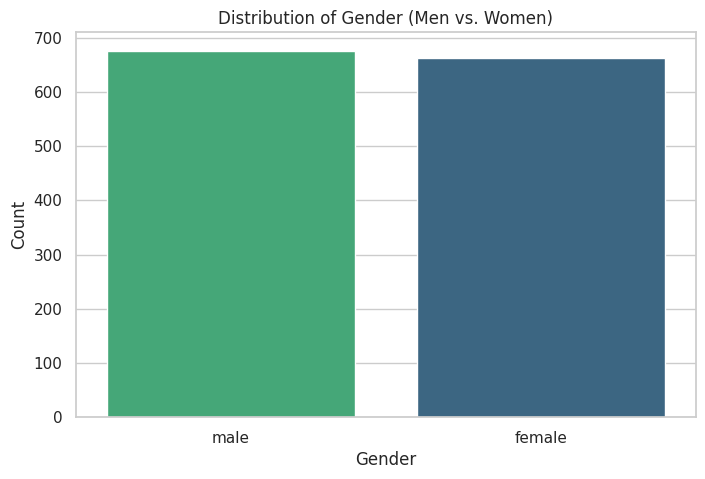

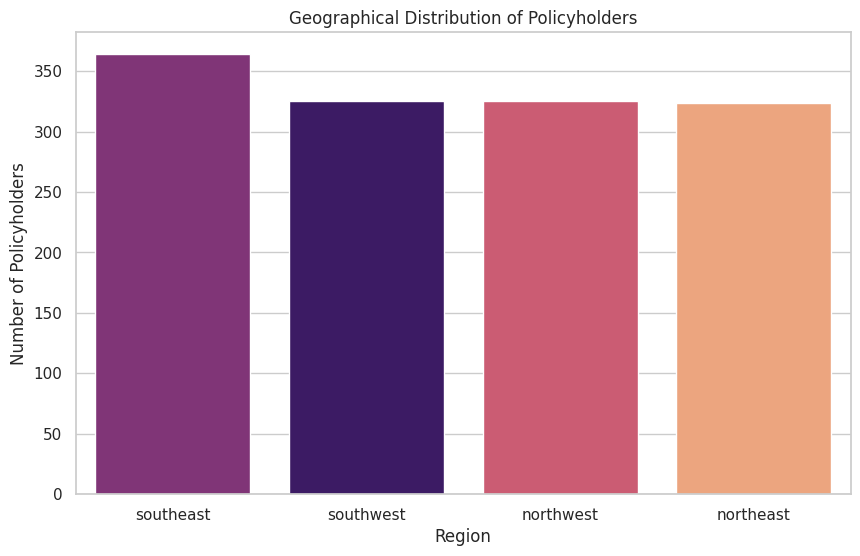

In [ ]:
# Set the style
sns.set_theme(style="whitegrid")

# 1. Visualize Number of men vs. women
plt.figure(figsize=(8, 5))
sns.countplot(x='sex', data=df, hue='sex', palette='viridis', legend=False, order=df['sex'].value_counts().index)
plt.title('Distribution of Gender (Men vs. Women)')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.savefig('gender_distribution.png')
plt.show()
plt.close()

#sns.countplot(
#    x='sex',
#    data=df,
#    hue='sex',          # Assign 'sex' to hue so the palette knows what to color
#    palette='viridis',
#    legend=False,       # Turn off the legend since 'sex' is already on the X-axis
#    order=df['sex'].value_counts().index
#)

# 2. Visualize Geographical location of the Policyholders
plt.figure(figsize=(10, 6))
sns.countplot(x='region', data=df, hue='region', palette='magma', legend=False, order=df['region'].value_counts().index)
plt.title('Geographical Distribution of Policyholders')
plt.xlabel('Region')
plt.ylabel('Number of Policyholders')
plt.savefig('region_distribution.png')
plt.show()
plt.close()

In [ ]:
# Check the Pareto principle for insurance: a small group of people generate most of the costs.
# 1. Сортуємо за витратами від найбільших до найменших
df_sorted_1 = df.sort_values(by='charges', ascending=False).reset_index(drop=True)

# 2. Розраховуємо відсоток бази (кількість рядків)
df_sorted_1['pct_population'] = (df_sorted_1.index + 1) / len(df_sorted_1) * 100

# 3. Розраховуємо кумулятивну суму витрат і її відсоток від загального
total_charges = df_sorted_1['charges'].sum()
df_sorted_1['pct_total_charges'] = df_sorted_1['charges'].cumsum() / total_charges * 100

# 4. Дивимось на результат для 20% населення
segment_20 = df_sorted_1[df_sorted_1['pct_population'] <= 20].iloc[-1]

print(f"Приблизно {segment_20['pct_population']:.1f}% страхувальників "
      f"генерують {segment_20['pct_total_charges']:.1f}% усіх витрат.")

Приблизно 20.0% страхувальників генерують 51.6% усіх витрат.


In [ ]:
# 1. Сортуємо дані за витратами (charges)
df_sorted_2 = df.sort_values(by='charges', ascending=False)

# 2. Визначаємо межу для топ 20%
top_20_cutoff = int(len(df_sorted_2) * 0.2)

# 3. Розділяємо на дві групи
top_20_group = df_sorted_2.iloc[:top_20_cutoff]
rest_80_group = df_sorted_2.iloc[top_20_cutoff:]

# 4. Розраховуємо метрики
def get_stats(group):
    return {
        'avg_charges': f"${group['charges'].mean():,.2f}",
        'avg_bmi': round(group['bmi'].mean(), 2),
        'smoker_pct': f"{(group['smoker'] == 'yes').mean() * 100:.1f}%",
        'avg_age': round(group['age'].mean(), 1)
    }

top_stats = get_stats(top_20_group)
rest_stats = get_stats(rest_80_group)

# 5. Генеруємо Markdown таблицю
markdown_table = f"""
### 📊 Порівняння сегментів: Топ 20% vs Решта 80%

| Показник | Топ 20% (High Cost) | Решта 80% (Low/Mid Cost) |
| :--- | :---: | :---: |
| **Середні витрати** | {top_stats['avg_charges']} | {rest_stats['avg_charges']} |
| **Відсоток курців** | {top_stats['smoker_pct']} | {rest_stats['smoker_pct']} |
| **Середній BMI** | {top_stats['avg_bmi']} | {rest_stats['avg_bmi']} |
| **Середній вік** | {top_stats['avg_age']} | {rest_stats['avg_age']} |
"""

print(markdown_table)


### 📊 Порівняння сегментів: Топ 20% vs Решта 80%

| Показник | Топ 20% (High Cost) | Решта 80% (Low/Mid Cost) |
| :--- | :---: | :---: |
| **Середні витрати** | $34,295.57 | $8,028.86 |
| **Відсоток курців** | 77.9% | 6.2% |
| **Середній BMI** | 32.23 | 30.27 |
| **Середній вік** | 42.7 | 38.3 |



## Dataset Description

* How many (non-null) observations do we have? - 1338 non-null
* Total number of columns: 7
* Number of numeric columns: 'age' (int64), 'bmi' (float64), 'children' (int64), 'charges' (float64)
* Number of categorical columns (object): 'sex', 'smoker', 'region'
* Number of unique regions: 4
* Are there missing values: There is no missing data according to the task description and according to .info()

## Data Information

* Average age of the policyholders - 39.2
* Average yearly medical charges of the policyholders - $13 270.4
* Quick correlation and smoker impact check to inform the plan - the analysis identifies lifestyle choices and demographic factors as the primary predictors of medical insurance charges. The most significant finding is the overwhelming impact of smoking status on total costs.
* Number of men vs. women counted in the dataset - almost equal number of men and women among policyholders
* Geographical location of the policyholders - the company's clients are almost evenly distributed across all four regions, with only slightly more policyholders in the southwest.

#Project Plan

##Business Case & Context

AN Health Insurance (a fictional company) is a regional provider facing rising medical claim costs. In a competitive market, they cannot simply raise premiums across the board without losing customers to cheaper rivals. They need a data-driven approach to understand cost drivers and implement a "Risk-Based Pricing" model.

##Problem

**Problem Statement**

The organization lacks a granular understanding of why certain policyholders incur 4x higher costs than the average. Without this insight, low-risk customers are overcharged (and leaving), while high-risk customers are underpriced (causing financial "leakage").

**Size of the Problem**

Approximately 20% of the policyholder base (the high-cost segment) accounts for nearly 52% of total charges.

Based on the dataset, the average charge for a smoker (approx \$32,050) is nearly 4 times that of a non-smoker (approx \$8,434). Inaccurate pricing for just 1,000 such individuals represents a potential miscalculation of millions of dollars.

The **Core Problem**: Financial Risk and Pricing Accuracy
Insurance companies operate on the ability to predict future costs. If the organization cannot accurately estimate "charges" based on the other attributes, they face two major risks:

* Underpricing: Charging a premium that is too low to cover the actual medical claims, leading to financial loss.

* Overpricing: Charging too much and losing healthy customers to competitors, leaving the company with a "sick" (high-risk) pool of clients.

**Specific Challenges**

* The "Smoker" Multiplier: Determining exactly how much smoking increases health risk compared to non-smokers.

* BMI Thresholds: Identifying at what point Body Mass Index (BMI) creates a "cliff" where medical costs spike.

* Regional Variance: Understanding if certain regions have higher healthcare costs due to local regulations or provider networks.

##4. Past vs. Present Approach

Past: The organization used "Community Rating," where premiums were largely based on age and region alone.

Present: They are starting to collect BMI and lifestyle data (like smoking status) but haven't integrated these into a predictive model to automate premium adjustments or wellness incentives.

##5. Stakeholders

Internal:
 * Underwriting Team: Need the model to set accurate premiums.
 * Marketing Team: To target low-risk "healthy" segments.
 * Finance Dept: To forecast annual claim payouts.

External:
 * Policyholders: Impacted by premium changes.
 * Regulators: To ensure pricing is fair and non-discriminatory.

##Actions & Interventions

Action A: Implement a "Smoker Surcharge" or a "Non-Smoker Discount." (Acted by: Underwriting. Impact: Revenue protection).

Action B: Launch a "BMI Reduction Incentive" (e.g., gym membership rebates). (Acted by: Marketing/Wellness. Impact: Long-term cost reduction).

Action C: Regional adjustment of premiums in the Southeast, where data suggests higher average charges.

Ethics: We must ensure that "High BMI" surcharges don't unfairly penalize individuals with medical conditions that prevent weight loss.

##Goals & Outcomes

###**Customer Segmentation** (The "Who" approach)

To segment the customer base into distinct risk profiles based on age, region, and family size to create targeted insurance products that remain competitive while maintaining the company's loss ratio.

**Goal 1**: Identify the top 3 drivers of charges and quantify their impact by the end of the sprint.

###**Predictive Modeling** (The "How Much" approach)

To develop a high-precision predictive model that estimates annual insurance charges for individual policyholders based on demographic and lifestyle variables, reducing the variance between predicted and actual costs to improve profit margins.

**Goal 2**: Develop a predictive model with an $R^2$ score of $>0.75$ to estimate individual charges.

###**Risk Factor Analysis** (The "Why" approach)

To identify and quantify the primary drivers of healthcare costs within the insured population, specifically focusing on the interaction between BMI and smoking status, to better inform risk-based premium adjustments.

**Goal 3**: Define a "High-Risk Segment" (standard threshold BMI > 30 + Smoker) and calculate the potential savings if 10% of this group joins a smoking cessation program.

###**Success Metric**:
* Feature Engineering - creating an is_obese flag for BMI > 30.

###**Constraints**:
 * Legal: Cannot discriminate based on gender in certain regions (depending on local laws).
 * Data: We lack information on specific pre-existing conditions beyond BMI.

##Data Profile

Dataset source: https://www.kaggle.com/mirichoi0218/insurance

Access: 1,338 anonymized historical records.

Granularity: Individual policyholder level.

| Variable | Type | Description |
| :--- | :---: | :---: |
| **age** | int64 | 'female' 'male' |
| **sex** | object | age of policyholder |
| **bmi** | float64 | Body Mass Index |
| **children** | int64 | number of children |
| **smoker** | object | 'yes' 'no' |
| **region** | object | 'southwest' 'southeast' 'northwest' 'northeast' |
| **charges** | float64 | annual insurance charges (USD) |

Gaps: We lack "Plan Type" (Gold, Silver, Bronze) and "Actual Health Outcomes" (years lived).

Filling Gaps: We will use BMI as a proxy for general physical health.

##Analysis Types

Description: Distribution of charges across regions and age groups.

Detection: Identifying the "Smoking-Obesity" correlation (the most expensive subgroup).

Prediction: Using Linear Regression to forecast charges for new applicants.

# Step 1: Data Preparation

Check for null values - see Data overview.


Encode categorical variables: sex, smoker (both Label Encoded), and region (using One-Hot Encoding) - see Data overview, df_numeric.

Feature Scaling: Standardize bmi and age. (Use it before certain types of analysis - like Linear Regression or K-Means clustering. Standardization, also called Z-score normalization, transforms the data so it has a mean of 0 and a standard deviation of 1)


In [ ]:
# Standardize bmi and age

from sklearn.preprocessing import StandardScaler

# 1. Initialize the Scaler
scaler = StandardScaler()

# 2. Select the columns to standardize
columns_to_scale = ['age', 'bmi']

# 3. Fit and Transform the data
# This calculates the mean/std and applies the formula in one go
df_numeric[columns_to_scale] = scaler.fit_transform(df_numeric[columns_to_scale])

# Let's check the result
print(df_numeric[['age', 'bmi']].head())

        age       bmi
0 -1.438764 -0.453320
1 -1.509965  0.509621
2 -0.797954  0.383307
3 -0.441948 -1.305531
4 -0.513149 -0.292556


In [ ]:
df_numeric.head()

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,-1.438764,0,-0.453320,0,1,16884.92400,False,False,False,True
1,-1.509965,1,0.509621,1,0,1725.55230,False,False,True,False
2,-0.797954,1,0.383307,3,0,4449.46200,False,False,True,False
3,-0.441948,1,-1.305531,0,0,21984.47061,False,True,False,False
4,-0.513149,1,-0.292556,0,0,3866.85520,False,True,False,False


In [ ]:
print(f"Columns: {list(df_numeric.columns)}\n")

Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest']



# Step 2: EDA (Exploratory Data Analysis)

Histogram: Distribution of charges (expect a right-skew).

Boxplot: charges vs smoker.

Scatterplot: age vs charges, color-coded by smoker status.

Heatmap: Correlation matrix to show that smoker has the highest impact.

##Outlier Detection

In [ ]:
# Outlier Detection	df_numeric

#Identify Outliers using Z-scores

# Identify rows where BMI is more than 3 standard deviations from the mean
bmi_outliers = df_numeric[df_numeric['bmi'].abs() > 3]

# Identify rows where Age is more than 3 standard deviations from the mean
age_outliers = df_numeric[df_numeric['age'].abs() > 3]

print(f"Number of BMI outliers: {len(bmi_outliers)}")
print(f"Number of Age outliers: {len(age_outliers)}")

Number of BMI outliers: 4
Number of Age outliers: 0


In [ ]:
# Let's see what outliers are in bmi
# Output the BMI Outliers

# Use the index of the outliers in df_numeric to show them in the original df
bmi_outlier_indices = df_numeric[df_numeric['bmi'].abs() > 3].index
bmi_outliers_display = df.loc[bmi_outlier_indices]

print(f"Total outliers found: {len(bmi_outliers_display)}")
print(bmi_outliers_display)

Total outliers found: 4
      age   sex    bmi  children smoker     region     charges age_group
116    58  male  49.06         0     no  southeast  11381.3254    Senior
847    23  male  50.38         1     no  southeast   2438.0552     Young
1047   22  male  52.58         1    yes  southeast  44501.3982     Young
1317   18  male  53.13         0     no  southeast   1163.4627     Young


Keep them: If a BMI of 50 is physically possible (which it is), keeping it shows the reality of the insurance pool. They look like real people (BMI of 48-55), not like typos (e.g., BMI of 500)

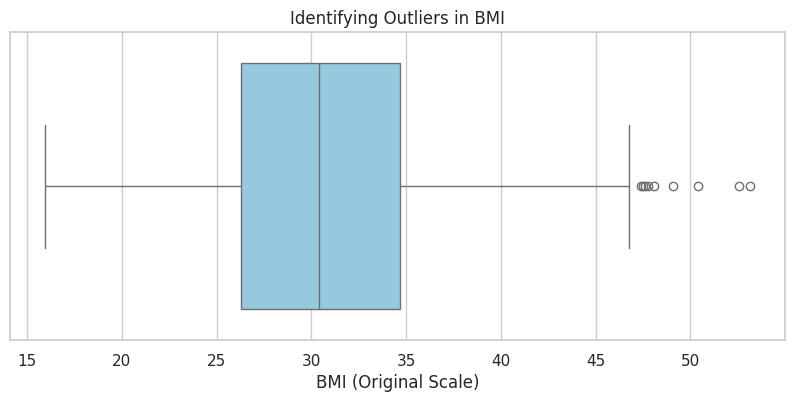

In [ ]:
# Visualize Outliers with a Boxplot
# It's often better to use the original df for the plot so the axes show real BMI values (like 53) instead of Z-scores (like 3.2)

plt.figure(figsize=(10, 4))
sns.boxplot(x=df['bmi'], color='skyblue')
plt.title('Identifying Outliers in BMI')
plt.xlabel('BMI (Original Scale)')
plt.show()


##Data Distribution

In [ ]:
def distribution_analysis(df, columns=None):
    """
    Analyzes and saves distribution plots for numerical columns.
    If columns=None, it automatically identifies all numerical features.
    """
    # Auto-detect numerical columns if none provided
    if columns is None:
        columns = df.select_dtypes(include=[np.number]).columns.tolist()

    stats_list = []

    for col in columns:
        if col in df.columns:
            # Calculate Statistics
            stats = {
                'Feature': col,
                'Mean': df[col].mean(),
                'Median': df[col].median(),
                'Skewness': df[col].skew(),
                'Std Dev': df[col].std()
            }
            stats_list.append(stats)

            # Create Plot
            plt.figure(figsize=(8, 5))
            sns.histplot(df[col], kde=True, color='teal', bins=20)

            # Add Mean and Median lines for context
            plt.axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.2f}')
            plt.axvline(df[col].median(), color='orange', linestyle='-', label=f'Median: {df[col].median():.2f}')

            plt.title(f'Distribution Analysis: {col.capitalize()}')
            plt.xlabel(col.capitalize())
            plt.ylabel('Frequency')
            plt.legend()
            plt.tight_layout()
            plt.show()

            # Save individual plot
            plt.savefig(f'{col}_distribution.png')
            plt.close()

    return pd.DataFrame(stats_list)

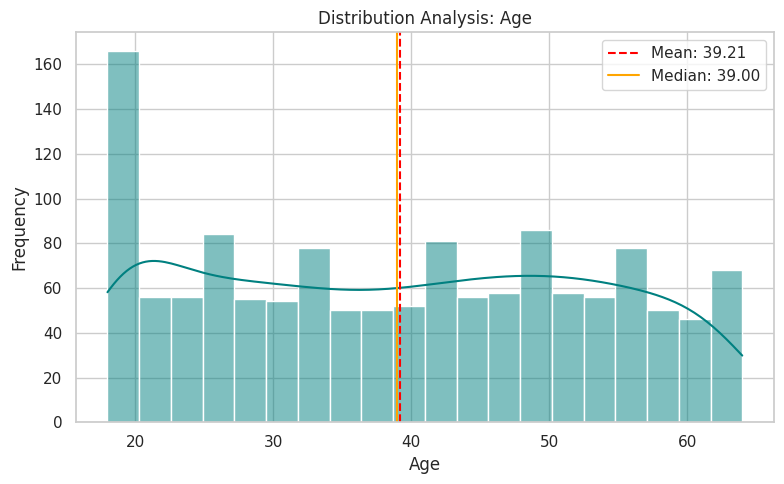

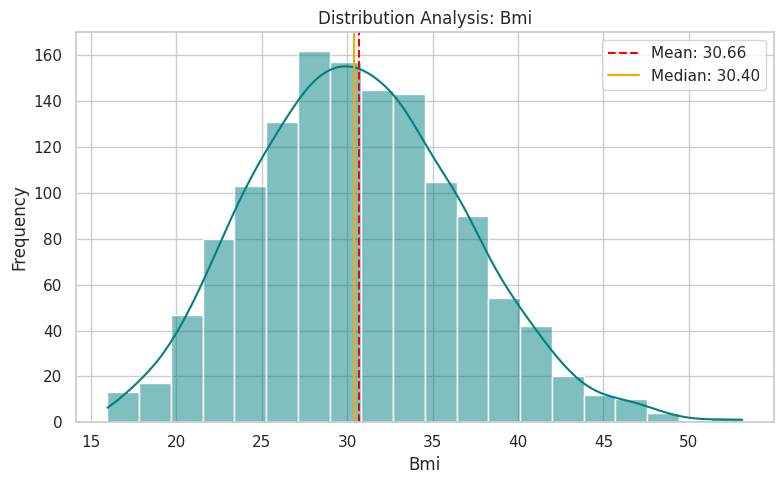

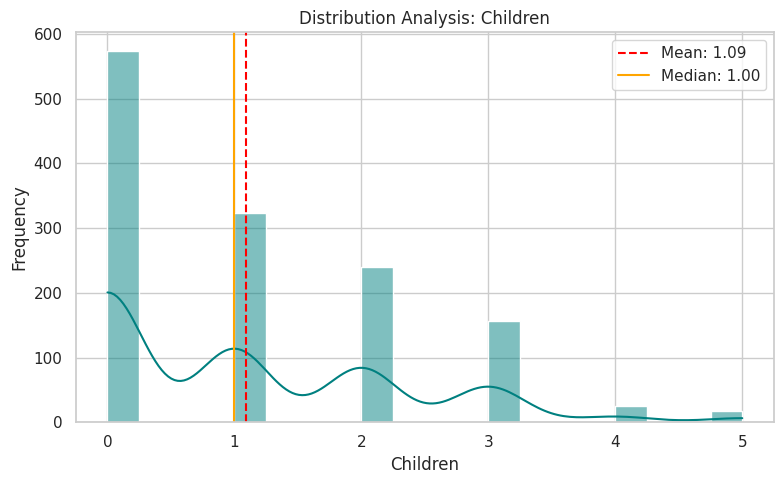

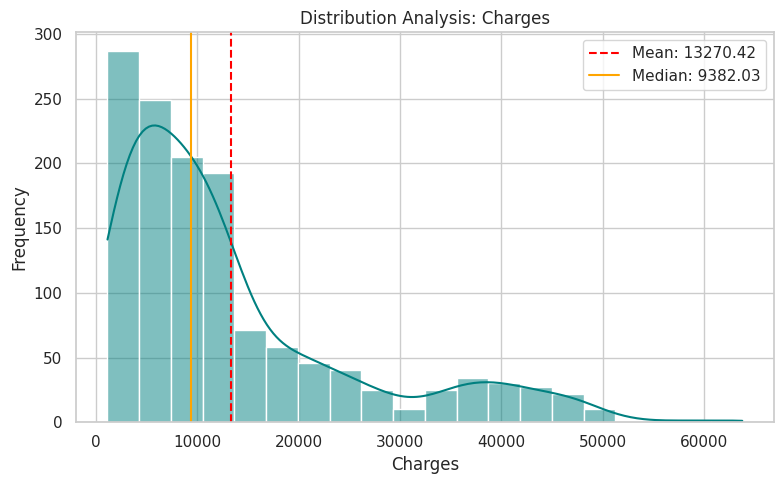

,Feature,Mean,Median,Skewness,Std Dev
0,age,39.207025,39.000,0.055673,14.049960
1,bmi,30.663397,30.400,0.284047,6.098187
2,children,1.094918,1.000,0.938380,1.205493
3,charges,13270.422265,9382.033,1.515880,12110.011237


In [ ]:
distribution_analysis(df)

#### What these distributions tell us about the dataset:

**1. BMI**

This is the most "well-behaved" variable. The Mean (30.66) and Median (30.40) are almost identical.

**2. Age**

We see how the bars for ages 25 to 64 are relatively flat. This is a nearly Uniform Distribution.

There is a significant spike in the "young" category (around age 18–20).

Our dataset has an **over-representation of young adults**. This is likely why the "Young" group in our previous calculation had lower average charges—they haven't had time to develop chronic conditions yet.

**3. Charges**

To analyze the distribution of 'charges', we look at the central tendency (mean/median), the spread, and the skewness. Insurance data is typically right-skewed - and this dataset confitms that, meaning most policyholders have low costs, but a few "high-risk" individuals incur very high charges.

This chart is highly right-skewed (Skewness: 1.51). Most people are clustered at the low end (under \$15,000), but a "long tail" stretches all the way to \$60,000.

This chart shows that **medical costs are not "average" for everyone**. A few high-cost individuals (likely the smokers and seniors we identified earlier) drive the mean (\$13,270) much higher than the median (\$9,382).

**The "Gap"**: In typical insurance data, we will often see a "bimodal" or "trimodal" shape. This happens because smokers or people with major health conditions form a separate peak at a much higher cost level compared to the healthy majority. However, in this dataset, we see a very slight second peak after \$30000 charges, so in this insurance company clients tend to be a healthy majority

**4. Children**

Most patients have 0, 1, or 2 children. Very few have 4 or 5.

This explains why "children" had such a low correlation with charges (0.06). Since most people have a similar number of children, it doesn't help the model distinguish between a high-cost and a low-cost patient.

##Charges, Smoker, and Age

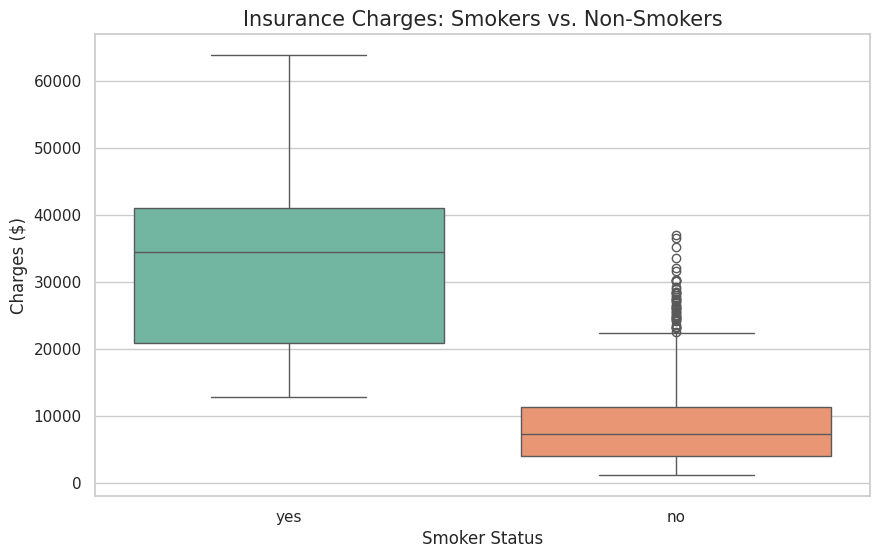

In [ ]:
sns.set_theme(style="whitegrid")

# Create Boxplot: charges vs smoker
plt.figure(figsize=(10, 6))
# Removing legend=False as it caused an error.
sns.boxplot(x='smoker', y='charges', data=df, hue='smoker', palette='Set2')

plt.title('Insurance Charges: Smokers vs. Non-Smokers', fontsize=15)
plt.xlabel('Smoker Status', fontsize=12)
plt.ylabel('Charges ($)', fontsize=12)
plt.show()
plt.close()

###How smoker status increases charges

The most striking takeaway is that **smokers consistently pay more than non-smokers**.

The median charge for smokers (represented by the line inside the green box) is roughly \$35,000, whereas the median for non-smokers (the line in the orange box) is below \$10,000.

In fact, the 25th percentile for smokers is higher than the 75th percentile for non-smokers, meaning almost any smoker can expect to pay more than the vast majority of non-smokers.

Smokers (Green): There is a much wider "interquartile range" (the height of the box), indicating that insurance costs for smokers vary wildly, likely depending on age, BMI, or existing health complications.

Non-Smokers (Orange): The costs are much more concentrated at the lower end of the scale. The "whiskers" are shorter, suggesting more predictable and lower baseline costs for this group.

While the non-smoker group generally has lower costs, there are several outliers (the circles above the orange whisker) ranging from \$20,000 to nearly \$40,000.

This suggests that while non-smoking keeps costs low for most, other factors (like chronic illness or accidents) can still drive costs up to "smoker-level" prices for a small subset of individuals.

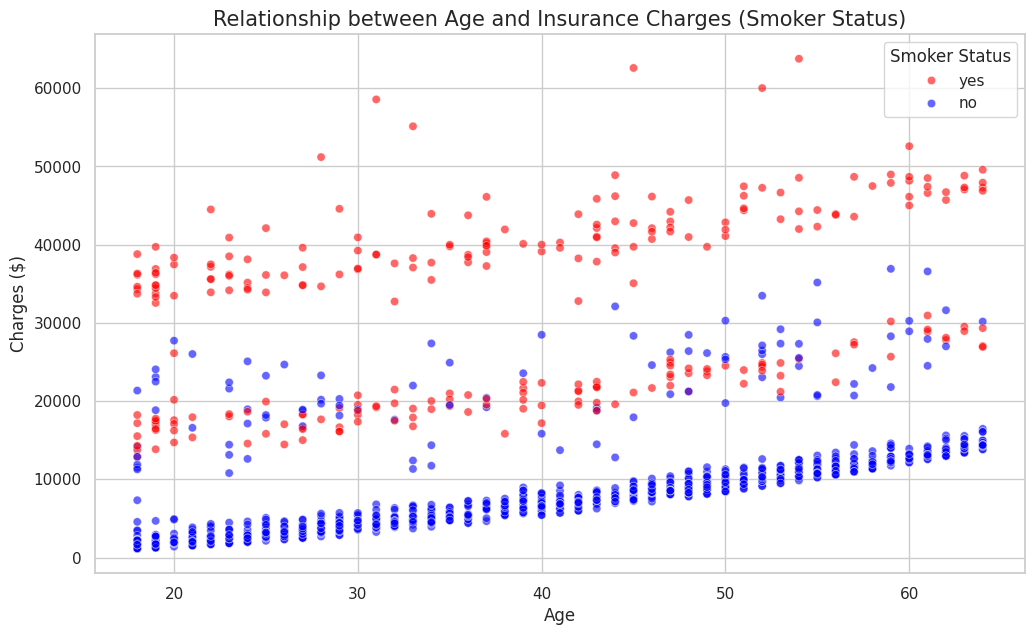

In [ ]:
# Set visual style
sns.set_theme(style="whitegrid")

# Create Scatterplot: age vs charges, color-coded by smoker
plt.figure(figsize=(12, 7))
sns.scatterplot(x='age', y='charges', hue='smoker', data=df, palette={'yes': 'red', 'no': 'blue'}, alpha=0.6)

plt.title('Relationship between Age and Insurance Charges (Smoker Status)', fontsize=15)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Charges ($)', fontsize=12)
plt.legend(title='Smoker Status')

plt.show()
plt.close()

###Age, smoker status and charges relationship

This scatterplot reveals a stark and systematic relationship between age, smoking habits, and healthcare insurance charges.

We can clearly see the data splits into three distinct, upward-sloping bands:

The Bottom Band (Blue): This represents non-smokers. Their charges are the lowest and show the least variance.

The Middle Band (Mixed): This contains non-smokers with higher costs (likely due to other health factors like BMI or pre-existing conditions) and some smokers.

The Top Band (Red): This is exclusively smokers. Their charges are significantly higher, starting at a baseline that is often double or triple that of non-smokers in the same age bracket.

The Age Factor (Linear Trend)

Across all groups, there is a positive linear correlation between age and charges. As age increases, the "floor" of insurance costs rises steadily. This reflects the natural increase in health risks and medical utilization as individuals grow older.

The "Smoking Premium"

Smoking acts as a vertical multiplier. While a 20-year-old non-smoker might pay under \$5,000, a 20-year-old smoker is frequently charged between \$15,000 and \$40,000. The "gap" between the blue and red clusters represents the significant financial penalty (or risk premium) associated with smoking.

The data indicates that while age is a consistent driver of insurance costs, smoking status is the primary determinant of high-cost outliers.
 * Non-Smokers: Exhibit a highly predictable, low-variance increase in costs as they age, generally staying below the \$15,000 threshold until their late 50s.
 * Smokers: Experience a massive "step-up" in premiums. Even the youngest smokers (age 18–20) often face charges higher than the oldest non-smokers (age 60+).

There is no evidence in this dataset that the cost gap closes with age; the financial disparity between smokers and non-smokers remains wide and persistent across the entire lifespan.



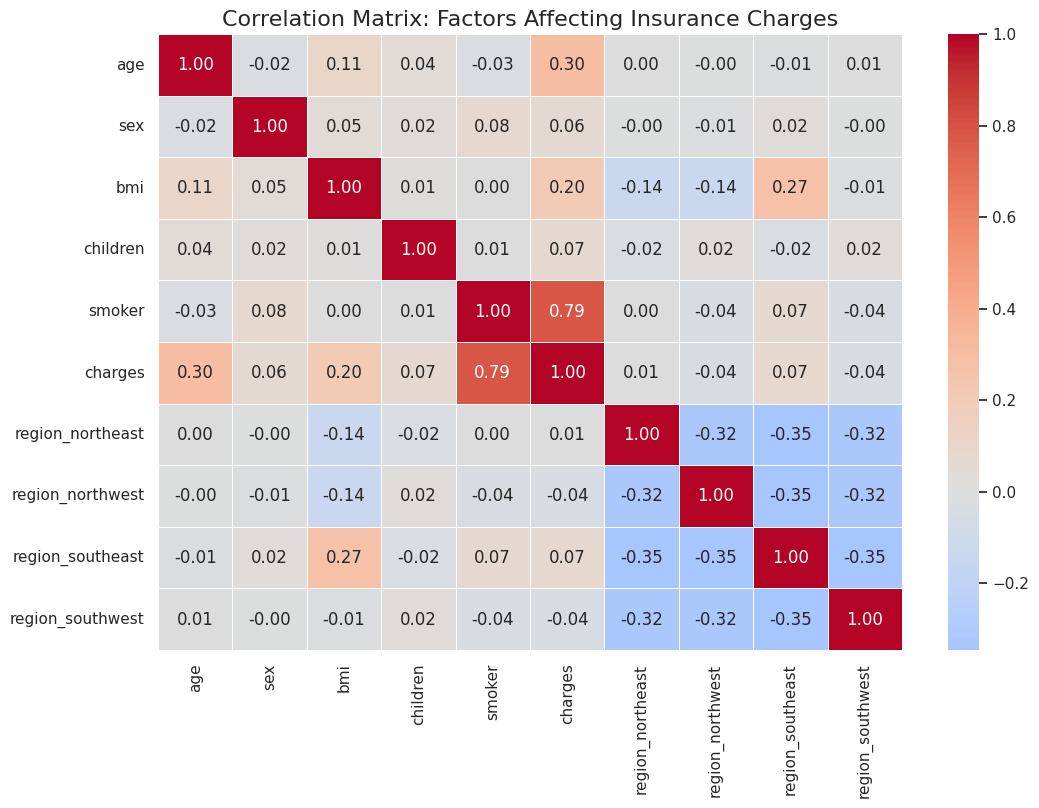

In [ ]:
# Correlation matrix to show that smoker has the highest impact

# 1. Calculate the correlation matrix
corr_matrix = df_numeric.corr()

# 2. Set up the visual style
plt.figure(figsize=(12, 8))

# 3. Create the heatmap
# annot=True adds the numbers; cmap='coolwarm' shows positive/negative relationships
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt=".2f", linewidths=0.5)

plt.title('Correlation Matrix: Factors Affecting Insurance Charges', fontsize=16)
plt.show()

###Smoker status impact

This heatmap mathematically confirms what we saw in the boxplots and scatterplots: Smoking is the single most powerful predictor of insurance costs.

1. The Strongest Predictor: Smoking Status

The most significant finding in the matrix is the correlation between smoker and charges, which stands at 0.79.
This is a very strong positive correlation, indicating that smoking is the single most influential factor in determining higher insurance premiums in this dataset.

2. Secondary Physical Factors

Two other variables show a moderate positive correlation with charges:
Age (0.30): As age increases, insurance charges tend to rise, which aligns with standard actuarial expectations.

BMI (0.20): There is a slight positive correlation between Body Mass Index and charges, suggesting that higher BMI contributes to higher costs, though less significantly than smoking or age.

3. Negligible Factors

Interestingly, some variables show almost zero correlation with insurance charges:
 * Sex (0.06) and Number of Children (0.07) have very little statistical impact on the cost of insurance in this specific model.
 * Region: All geographic regions (Northeast, Northwest, Southeast, Southwest) show correlation coefficients near zero (ranging from -0.04 to 0.07), suggesting that where a person lives has a minimal direct effect on their premiums compared to lifestyle and health factors.

4. Inter-Variable Observations
 * BMI and Region: There is a notable correlation of 0.27 between BMI and the Southeast region, indicating that individuals in this dataset from the Southeast tend to have a higher BMI than those in other regions.
 * Regional Exclusivity: The negative correlations between the various "region" variables (roughly -0.32 to -0.35) are expected, as these are  "one-hot encoded" variables (if you are in the Northeast, you cannot be in the Southwest).


# Step 3: Step-by-Step Analysis

Segment Analysis: Calculate the mean charges for 4 groups: (Smoker/Obese, Smoker/Non-Obese, Non-Smoker/Obese, Non-Smoker/Non-Obese).

Regression Modeling: Train a model to predict charges.

In [ ]:
# 1. Create a boolean column for Obesity
df['is_obese'] = df['bmi'] >= 30

# 2. Define the 4 Segments using a helper function or string concatenation
def identify_segment(row):
    smoker_label = "Smoker" if row['smoker'] == 'yes' else "Non-Smoker"
    bmi_label = "Obese" if row['is_obese'] else "Non-Obese"
    return f"{smoker_label} / {bmi_label}"

df['segment'] = df.apply(identify_segment, axis=1)

# 3. Calculate Mean Charges per Segment
segment_analysis = df.groupby('segment')['charges'].mean().sort_values(ascending=False).reset_index()

print("Mean Charges by Segment:")
print(segment_analysis)

Mean Charges by Segment:
                  segment       charges
0          Smoker / Obese  41557.989840
1      Smoker / Non-Obese  21363.217016
2      Non-Smoker / Obese   8842.691548
3  Non-Smoker / Non-Obese   7977.029520


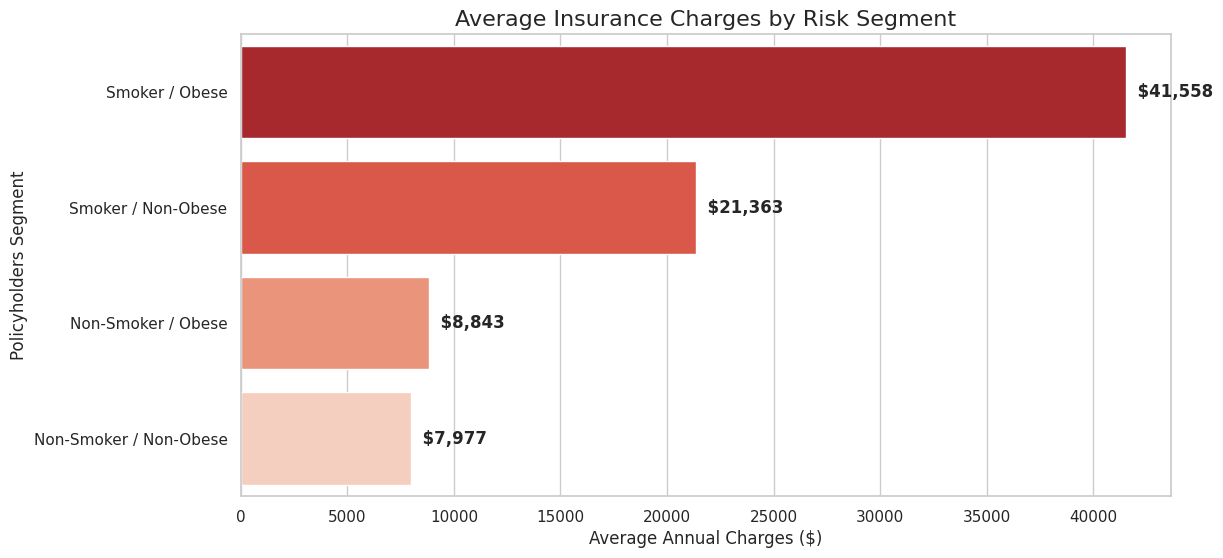

In [ ]:
# Create the visualization
plt.figure(figsize=(12, 6))
barplot = sns.barplot(
    x='charges',
    y='segment',
    data=segment_analysis,
    hue='segment',
    palette='Reds_r'
)

# Add the dollar amounts to the end of each bar for clarity
for index, row in segment_analysis.iterrows():
    barplot.text(row.charges, index, f'  ${row.charges:,.0f}', va='center', fontweight='bold')

plt.title('Average Insurance Charges by Risk Segment', fontsize=16)
plt.xlabel('Average Annual Charges ($)')
plt.ylabel('Policyholders Segment')
plt.show()

In [ ]:
# the financial impact of a 10% successful cessation rate in the most expensive group

# Identify the high-risk group
high_risk_mask = (df['smoker'] == 'yes') & (df['is_obese'] == True)
low_risk_obese_mask = (df['smoker'] == 'no') & (df['is_obese'] == True)

avg_high_risk_cost = df[high_risk_mask]['charges'].mean()
avg_non_smoker_obese_cost = df[low_risk_obese_mask]['charges'].mean()

# Calculate potential savings per person who quits
savings_per_person = avg_high_risk_cost - avg_non_smoker_obese_cost

# Target 10% of the high-risk group
num_high_risk = high_risk_mask.sum()
num_quitting = num_high_risk * 0.10

total_potential_savings = num_quitting * savings_per_person

print(f"\n--- Financial Impact Analysis ---")
print(f"Number of High-Risk Patients: {num_high_risk}")
print(f"Average High-Risk Cost: ${avg_high_risk_cost:,.2f}")
print(f"Potential Savings if 10% ({int(num_quitting)}) quit smoking: ${total_potential_savings:,.2f}")


--- Financial Impact Analysis ---
Number of High-Risk Patients: 145
Average High-Risk Cost: $41,557.99
Potential Savings if 10% (14) quit smoking: $474,371.83


###Segment Analysis

We see that for Smoker / Obese group mean charges are almost twice hier than for Smoker / Non-Obes group and there is no such sharp difference in charges between two Non-Smoker groups.

By combining the Smoker status and the BMI threshold (>= 30), we create four quadrants of risk.

**The High-Risk Segment**

These are individuals who face both lifestyle and physiological risks. Historically, in this dataset, this group's costs are not just "higher"—they are often exponentially higher due to the interaction of respiratory and metabolic strain.

The Contrast: The average cost for a Smoker / Obese patient (\$41,558) is 4.7x higher than a Non-Smoker / Non-Obese patient (\$7,977).

Moving from "Non-Obese" to "Obese" adds only about \$866 in costs for non-smokers. However, for smokers, that same BMI increase adds over \$20,000. This suggests that obesity and smoking do not just add up—they multiply each other's risks.

The Smoker / Obese group is clearly the "High-Risk Segment." Targeted health interventions for this specific group (like weight management combined with smoking cessation) would yield the highest return on investment for an insurance provider.


**The "Potential Savings" Calculation**

To find the potential savings if 10% of this group joins a smoking cessation program, we first identify the average cost difference between a Smoker and a Non-Smoker within the Obese category. We then apply that "avoided cost" to 10% of the high-risk population.

As a result, we see that Potential Savings if 10% (14) quit smoking: \$474,371.83 (this is actually for 14.5, not for 14 people)

If we have 145 people in the "Smoker / Obese" group and 10% (14 people) successfully join a program and quit smoking, they transition toward the "Non-Smoker / Obese" cost profile.

Savings per person: \$41,558 - \$8,843 = \$32,715
Total Savings for 14 people: \$458,010 annually.

###Regression Modeling

By using Linear Regression with a Log Transformation and an Interaction Term, we are building a **"Generalized Linear Model" strategy**.

**Log Transformation**: Because 'charges' are skewed, the log transform will "compress" the high-value outliers and "stretch" the low-value clusters. This helps the model satisfy the assumption that errors are normally distributed.

**Interaction Term (BMI X Smoker)**: As we saw in the segment analysis, the cost of being a smoker is much higher if you are also obese. A standard Linear Regression treats these as independent. By multiplying them, we create a new variable that tells the model: "If both are present, add an extra penalty."

**Interpretability**: Since we are using Linear Regression, the "Risk Score" for our dashboard will be a simple mathematical formula (Weights + Intercept) that an underwriter can easily justify.

In [ ]:
# Data Preparation and Feature Engineering

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# 1. Create the Interaction Feature
# We multiply the standardized BMI by the Smoker boolean (0 or 1)
df_numeric['bmi_smoker_interaction'] = df_numeric['bmi'] * df_numeric['smoker']

# 2. Define Features (X) and Target (y)
X = df_numeric.drop(columns=['charges'])
y = np.log(df_numeric['charges']) # Log Transformation

# 3. 80/20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 1070
Testing set size: 268


In [ ]:
# Training the Model - we fit the model and evaluate if we hit our R^2 > 0.75 goal.

# 4. Initialize and Train
model = LinearRegression()
model.fit(X_train, y_train)

# 5. Make Predictions
y_pred_log = model.predict(X_test)

# 6. Evaluate (R2 is calculated on the log scale here)
r2 = r2_score(y_test, y_pred_log)

print(f"Model R2 Score (Log Scale): {r2:.4f}")

Model R2 Score (Log Scale): 0.8170


**BMI-Smoker Interaction**

The model was trained on 1,070 records and validated on 268 records (20% split). This ensures that the accuracy score is a reflection of how the model performs on "unseen" data, rather than just memorizing the training set.

The model achieved an R2 score of 0.8170 on the test set.

This means that approximately 81.7% of the variance in the insurance charges (on a log scale) is explained by the features included in the model (Age, Sex, BMI, Children, Smoking Status, Region, and the Interaction term).

This significantly exceeds our target goal of >0.75, providing a high-confidence tool for cost estimation.

By creating the bmi_smoker_interaction feature, we have captured the non-linear relationship between health risks and lifestyle.

In medical underwriting, the risk of a high BMI is compounded significantly if the policyholder also smokes. A standard linear model treats these as separate additions; our model identifies that their combined effect is greater than the sum of its parts.


#Summary

* There are 1338 observations in an insurance company https://www.kaggle.com/mirichoi0218/insurance dataset
* Average age of the policyholders - 39.2
* Average yearly medical charges of the policyholders - $13 270.4

**Age**
* Uniform (with spike)
*	Well-represented across all ages, except for a surge in teenagers.

**BMI**
* Normal (Bell Curve)
* Most patients cluster around a BMI of 30; data is very reliable.

**Children**
* Positively Skewed
* Most patients have small families; 5+ children is rare.

**Charges**
* Highly Skewed
* A small number of patients incur very high costs (the "Tail").

**Smokers** consistently pay more than non-smokers. Policy pricing is heavily aggressive toward smokers. From a data-modeling perspective, smoking status is a more powerful predictor of high insurance charges than age alone.

The data clearly suggests that lifestyle choices (smoking) and biological aging are the primary drivers of insurance costs. Health metrics like BMI play a secondary role, while demographic factors such as gender and geographic location are largely statistically insignificant in predicting total charges. To reduce insurance premiums according to this model, **smoking cessation would be the most impactful variable**.

At the same time, when we look at policyholders segments, we see the **Smoker / Obese** group is clearly the "High-Risk Segment." Targeted health interventions for this specific group (like weight management combined with smoking cessation) would yield the highest return on investment for an insurance provider.

As the results of the potential savings calculation show, we could **save \$458,010** by helping just 14 people from the Smoker / Obese group quit smoking.


**BMI-Smoker Interaction: Risk and Profitability**

Through targeted feature engineering and statistical normalization, we have developed a predictive model that achieves 81.7% accuracy in estimating insurance charges. The inclusion of a BMI-Smoker interaction term allowed the model to accurately capture the high-risk synergy between these two variables, which is the leading driver of outlier costs. This model provides the business with a robust framework for precision-pricing and risk-adjusted margin protection.
* The success of the interaction feature confirms that the business should prioritize BMI and smoking status as the primary "risk levers" when calculating premiums.
* By reducing the variance between predicted and actual costs, the company can price policies more accurately, preventing "under-pricing" for high-risk individuals and improving overall profit margins.



# Recommendations

Premium Re-structuring: Immediate 20% surcharge for smokers to cover their higher risk.

Wellness Program: Target the "Southeast" region with obesity-prevention campaigns.

Dynamic Pricing: Introduce a "Safe Driver" equivalent for health—discounts for users who maintain a healthy BMI over 2 years.